# Governor Comparison Bar Charts

Read benchmark summary CSV files from `tests/**` and plot grouped bar charts
by CPU governor (`performance`, `ondemand`, `2.25GHz`, `everest`, `pulse`)
with error bars computed from per-run samples.

In [22]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [23]:
# User settings
BASE_DIR = Path.cwd()
if BASE_DIR.name != 'tests':
    BASE_DIR = BASE_DIR / 'tests'

GOVERNORS = ['performance', 'ondemand', '2.25GHz', 'everest', 'pulse']
METRICS = [
    'Total runtime [s]',
    'Average total power [W]',
    'Total energy [J]',
    'EDP [J*s]',
]
GOVERNOR_LABELS = {
    'performance': 'Performance',
    'ondemand': 'Ondemand',
    '2.25GHz': '2.25GHz (Fixed)',
    'everest': 'EVeREST-C',
    'pulse': 'PULSE (ours)',
}
GOVERNOR_COLORS = {
    # Example overrides:
    'performance': "#152B3A",
    'ondemand': "#29526F",
    '2.25GHz': "#3F7CA7",
    'everest': "#619ECA",
    'pulse': "#A8CEE9",
    
}
SPECCPU_BG_COLOR = 'lightgray'
SPECHPC_BG_COLOR = 'gray'
SPECCPU_TEXT_COLOR = 'gray'
SPECHPC_TEXT_COLOR = 'dimgray'
EXCLUDED_BENCHMARKS = {'snap'}
FIGSIZE = (max(12, 0.8 * 12), 6)
SAVE_PLOTS = False
OUT_DIR = BASE_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [24]:
def discover_summary_files(base_dir: Path, governors: list[str]) -> list[Path]:
    files: list[Path] = []
    for gov in governors:
        files.extend(base_dir.rglob(f'{gov}_summary_*.csv'))
    return sorted(set(files))


def benchmark_from_path(csv_path: Path, governor: str) -> str:
    prefix = f'{governor}_summary_'
    stem = csv_path.stem
    if stem.startswith(prefix):
        return stem[len(prefix):]
    return stem


def suite_from_path(csv_path: Path, base_dir: Path) -> str:
    try:
        rel = csv_path.relative_to(base_dir)
        return rel.parts[0] if len(rel.parts) else 'unknown'
    except ValueError:
        return csv_path.parts[-4] if len(csv_path.parts) >= 4 else 'unknown'


def suite_order_key(suite: str) -> tuple[int, str]:
    if suite == 'SPECcpu':
        return (1, suite)
    if suite == 'SPEChpc':
        return (2, suite)
    return (0, suite)


def summarize_csv(csv_path: Path, governor: str) -> dict:
    df = pd.read_csv(csv_path)
    benchmark = benchmark_from_path(csv_path, governor)

    if 'benchmark' in df.columns and df['benchmark'].notna().any():
        benchmark = str(df['benchmark'].dropna().iloc[0])

    run_df = df[df['subfolder'] != 'Average'].copy() if 'subfolder' in df.columns else df.copy()
    avg_df = df[df['subfolder'] == 'Average'].copy() if 'subfolder' in df.columns else pd.DataFrame()

    suite = suite_from_path(csv_path, BASE_DIR)

    row = {
        'suite': suite,
        'benchmark': benchmark,
        'governor': governor,
        'file': str(csv_path),
        'n_runs': int(len(run_df)),
    }

    for metric in METRICS:
        if metric not in df.columns:
            row[f'{metric}_mean'] = np.nan
            row[f'{metric}_std'] = np.nan
            row[f'{metric}_csv_avg'] = np.nan
            continue

        avg_val = pd.to_numeric(avg_df[metric], errors='coerce').dropna() if not avg_df.empty else pd.Series(dtype=float)
        row[f'{metric}_csv_avg'] = float(avg_val.iloc[0]) if len(avg_val) else np.nan

        if not run_df.empty:
            vals = pd.to_numeric(run_df[metric], errors='coerce').dropna()
            row[f'{metric}_mean'] = float(vals.mean()) if len(vals) else np.nan
            row[f'{metric}_std'] = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
        elif not avg_df.empty:
            row[f'{metric}_mean'] = float(avg_val.iloc[0]) if len(avg_val) else np.nan
            row[f'{metric}_std'] = 0.0
        else:
            row[f'{metric}_mean'] = np.nan
            row[f'{metric}_std'] = np.nan

    return row


summary_files = discover_summary_files(BASE_DIR, GOVERNORS)
print(f'Found {len(summary_files)} summary CSV files.')
summary_files[:10]

Found 135 summary CSV files.


[PosixPath('/mnt/REPACSS/home/li29729/Research2025/CPUfreq/PrimeMicroBenchmarks/tests/AMG/AMDzen4c/2.25GHz/2.25GHz_summary_amg.csv'),
 PosixPath('/mnt/REPACSS/home/li29729/Research2025/CPUfreq/PrimeMicroBenchmarks/tests/AMG/AMDzen4c/everest/everest_summary_amg.csv'),
 PosixPath('/mnt/REPACSS/home/li29729/Research2025/CPUfreq/PrimeMicroBenchmarks/tests/AMG/AMDzen4c/ondemand/ondemand_summary_amg.csv'),
 PosixPath('/mnt/REPACSS/home/li29729/Research2025/CPUfreq/PrimeMicroBenchmarks/tests/AMG/AMDzen4c/performance/performance_summary_amg.csv'),
 PosixPath('/mnt/REPACSS/home/li29729/Research2025/CPUfreq/PrimeMicroBenchmarks/tests/AMG/AMDzen4c/pulse/pulse_summary_amg.csv'),
 PosixPath('/mnt/REPACSS/home/li29729/Research2025/CPUfreq/PrimeMicroBenchmarks/tests/HPCG/AMDzen4c/2.25GHz/2.25GHz_summary_hpcg.csv'),
 PosixPath('/mnt/REPACSS/home/li29729/Research2025/CPUfreq/PrimeMicroBenchmarks/tests/HPCG/AMDzen4c/everest/everest_summary_hpcg.csv'),
 PosixPath('/mnt/REPACSS/home/li29729/Research2025/C

In [25]:
records = []
for csv_path in summary_files:
    gov = csv_path.stem.split('_summary_')[0]
    if gov in GOVERNORS:
        records.append(summarize_csv(csv_path, gov))

summary = pd.DataFrame(records)
if summary.empty:
    raise RuntimeError('No matching summary CSV files found.')

summary['suite_order'] = summary['suite'].map(lambda s: suite_order_key(str(s))[0])
summary = summary.sort_values(['suite_order', 'suite', 'benchmark', 'governor']).reset_index(drop=True)
summary = summary.drop(columns=['suite_order'])
summary.head()

,suite,benchmark,governor,file,n_runs,Total runtime [s]_csv_avg,Total runtime [s]_mean,Total runtime [s]_std,Average total power [W]_csv_avg,Average total power [W]_mean,Average total power [W]_std,Total energy [J]_csv_avg,Total energy [J]_mean,Total energy [J]_std,EDP [J*s]_csv_avg,EDP [J*s]_mean,EDP [J*s]_std
0,AMG,amg,2.25GHz,/mnt/REPACSS/home/li29729/Research2025/CPUfreq...,5,449.38,449.382,2.369107,613.12,613.120,2.535123,274777.08,274777.080,2097.410321,1.234836e+08,1.234836e+08,1.553941e+06
1,AMG,amg,everest,/mnt/REPACSS/home/li29729/Research2025/CPUfreq...,5,482.33,482.332,12.328178,534.00,534.006,12.319703,256909.58,256909.574,4592.851632,1.239375e+08,1.239375e+08,4.695895e+06
2,AMG,amg,ondemand,/mnt/REPACSS/home/li29729/Research2025/CPUfreq...,5,460.61,460.610,9.392992,595.84,595.834,7.975198,273635.78,273635.780,3070.956827,1.260575e+08,1.260575e+08,3.783527e+06
3,AMG,amg,performance,/mnt/REPACSS/home/li29729/Research2025/CPUfreq...,5,456.90,456.900,3.578107,608.78,608.782,3.658363,277416.61,277416.608,2740.080162,1.267580e+08,1.267580e+08,2.137260e+06
4,AMG,amg,pulse,/mnt/REPACSS/home/li29729/Research2025/CPUfreq...,5,526.83,526.828,0.647047,453.72,453.724,5.559171,239050.84,239050.844,3124.747981,1.259396e+08,1.259396e+08,1.763125e+06


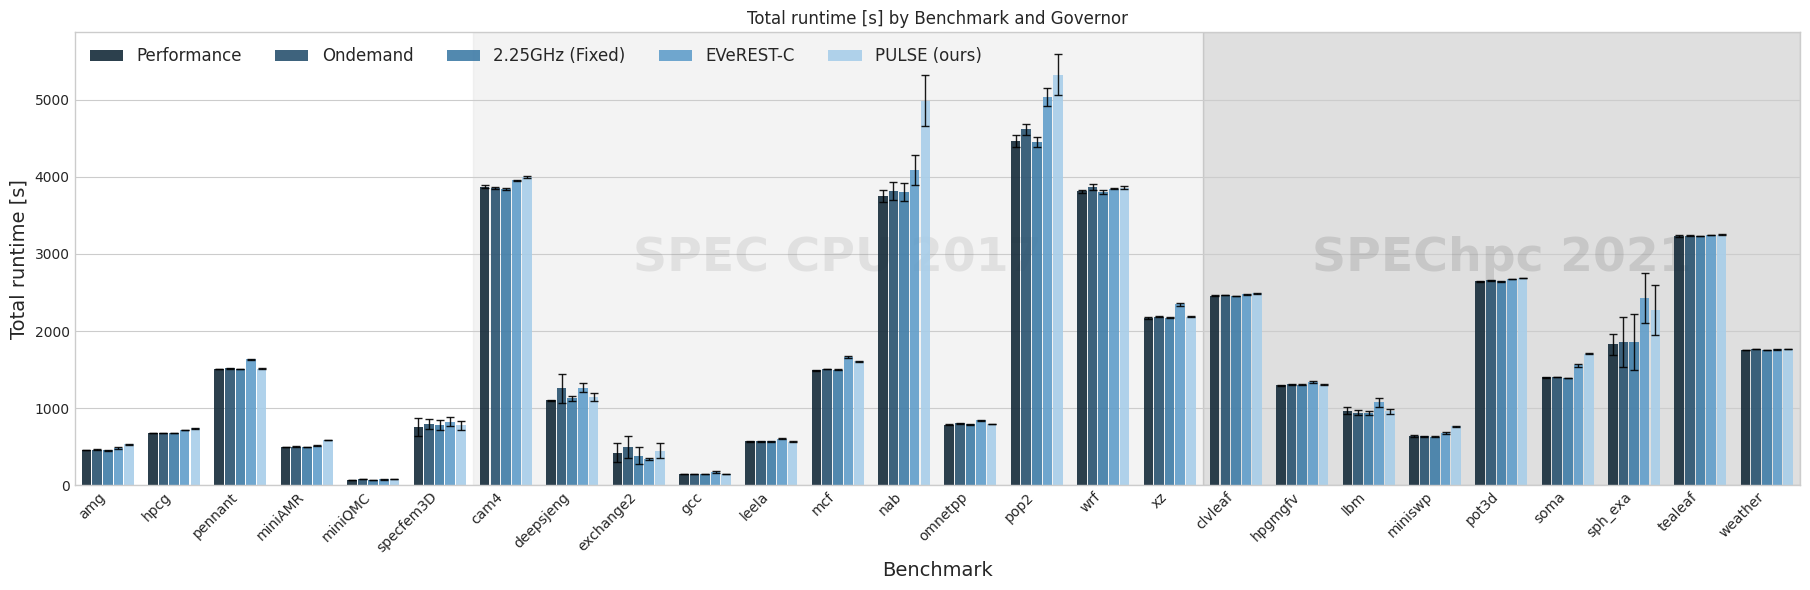

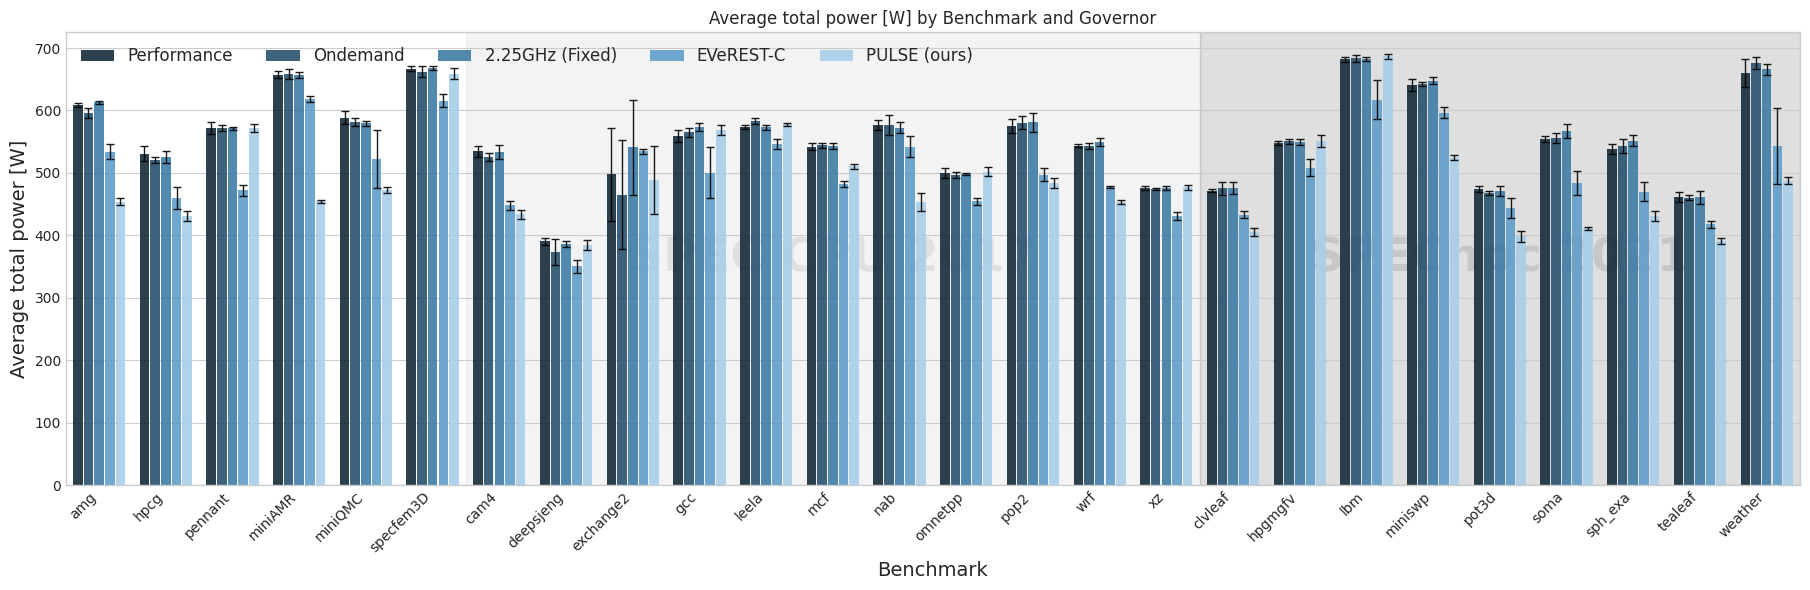

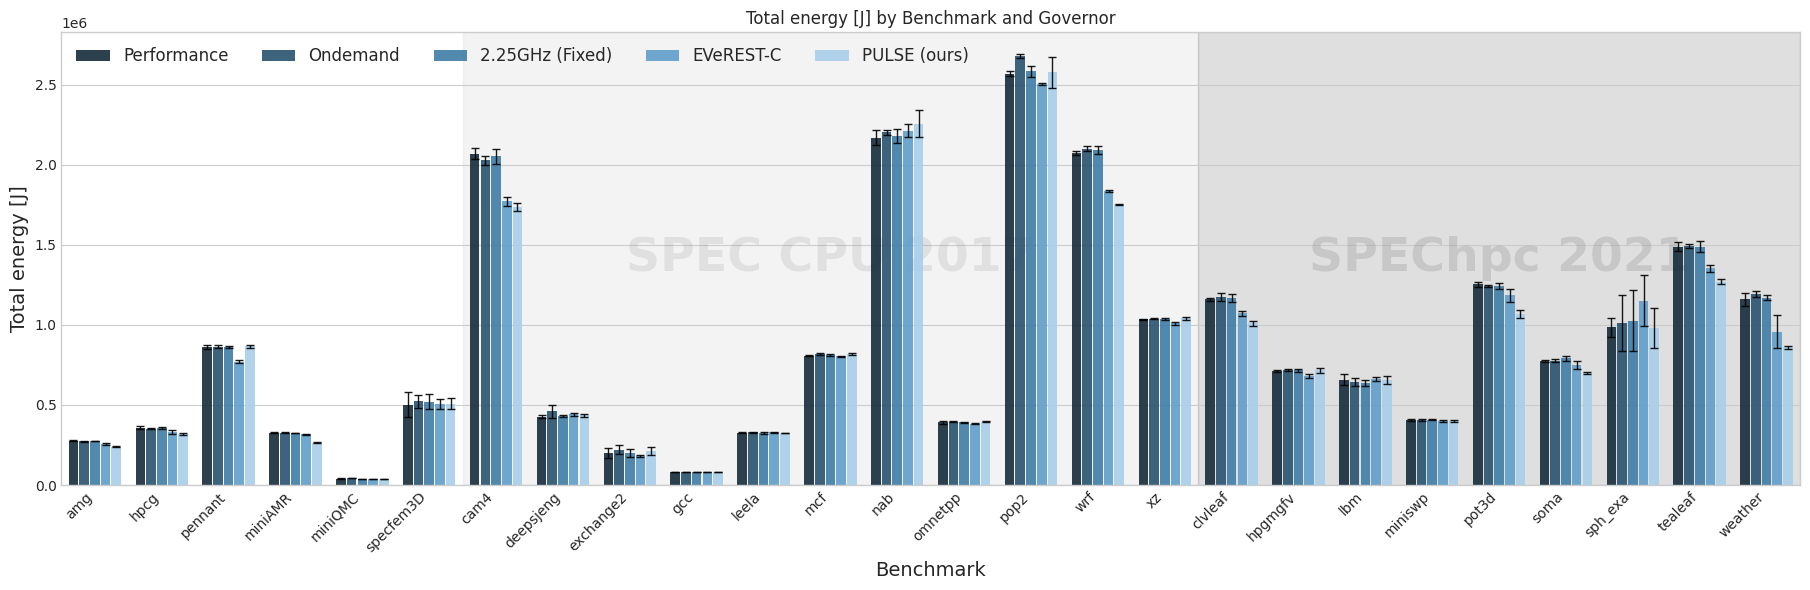

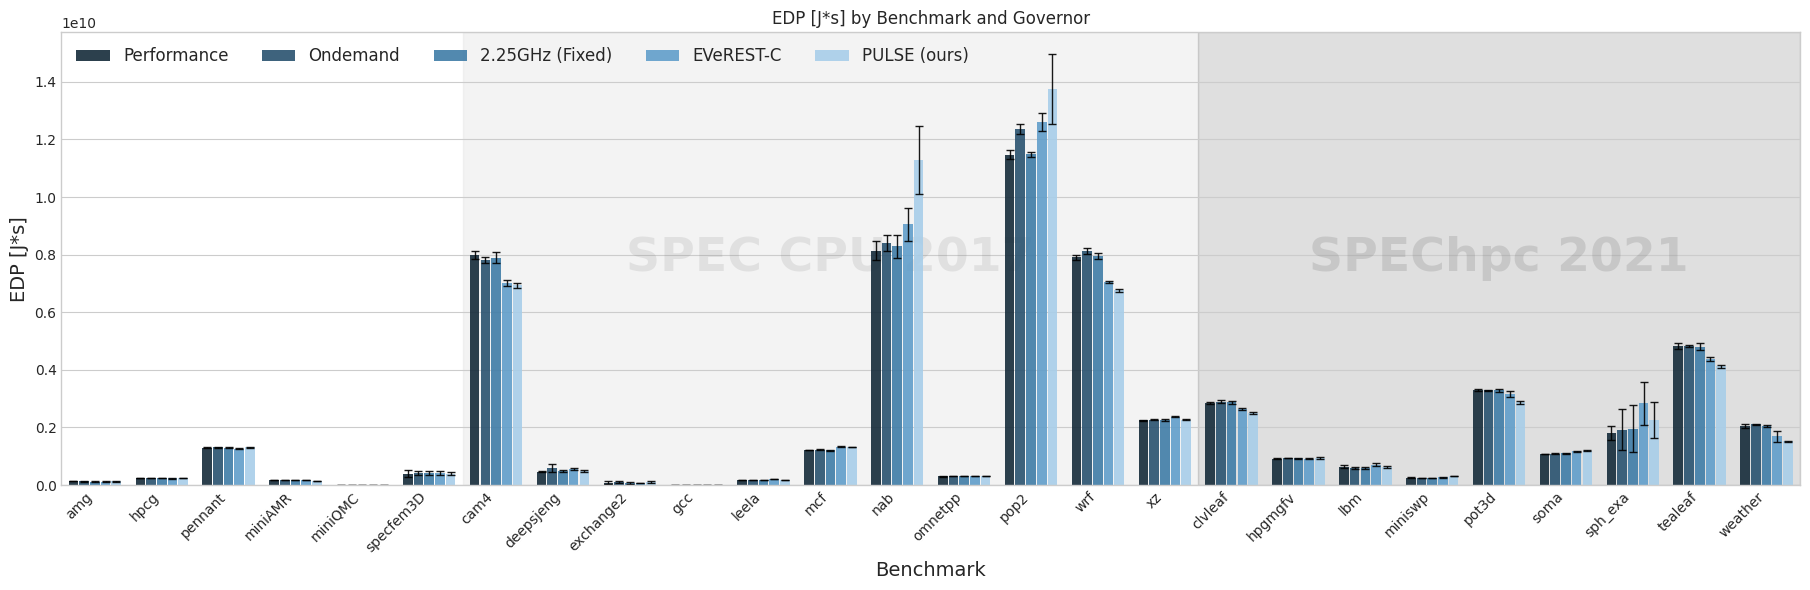

In [26]:
def plot_grouped_metric(df: pd.DataFrame, metric: str, governors: list[str]) -> None:
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'

    piv_mean = df.pivot_table(index=['suite', 'benchmark'], columns='governor', values=mean_col, aggfunc='first')
    piv_std = df.pivot_table(index=['suite', 'benchmark'], columns='governor', values=std_col, aggfunc='first')
    piv_mean = piv_mean[~piv_mean.index.get_level_values('benchmark').isin(EXCLUDED_BENCHMARKS)]
    piv_std = piv_std[~piv_std.index.get_level_values('benchmark').isin(EXCLUDED_BENCHMARKS)]

    bench_order = sorted(piv_mean.index.tolist(), key=lambda x: (suite_order_key(str(x[0])), str(x[1])))
    piv_mean = piv_mean.reindex(index=bench_order, columns=governors)
    piv_std = piv_std.reindex(index=bench_order, columns=governors)

    x = np.arange(len(bench_order), dtype=float)
    n = len(governors)
    slot = 0.8 / n
    width = slot * 0.9

    fig, ax = plt.subplots(figsize=(max(12, 0.7 * len(bench_order)), 6))

    # Shade benchmark groups for SPEC suites.
    suite_blocks: dict[str, list[tuple[int, int]]] = {}
    if bench_order:
        start = 0
        current_suite = bench_order[0][0]
        for idx in range(1, len(bench_order)):
            suite = bench_order[idx][0]
            if suite != current_suite:
                suite_blocks.setdefault(current_suite, []).append((start, idx - 1))
                start = idx
                current_suite = suite
        suite_blocks.setdefault(current_suite, []).append((start, len(bench_order) - 1))

    for left, right in suite_blocks.get('SPECcpu', []):
        ax.axvspan(left - 0.5, right + 0.5, color=SPECCPU_BG_COLOR, alpha=0.25, zorder=0)

    # Add large background text labels for SPEC groups.
    for left, right in suite_blocks.get('SPECcpu', []):
        center = (left + right) / 2.0
        ax.text(
            center,
            0.5,
            'SPEC CPU 2017',
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='center',
            fontsize=34,
            color=SPECCPU_TEXT_COLOR,
            alpha=0.16,
            weight='bold',
            zorder=1,
        )
    for left, right in suite_blocks.get('SPEChpc', []):
        center = (left + right) / 2.0
        ax.text(
            center,
            0.5,
            'SPEChpc 2021',
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='center',
            fontsize=34,
            color=SPECHPC_TEXT_COLOR,
            alpha=0.2,
            weight='bold',
            zorder=1,
        )

    for i, gov in enumerate(governors):
        vals = piv_mean[gov].to_numpy(dtype=float) if gov in piv_mean.columns else np.full(len(bench_order), np.nan)
        errs = piv_std[gov].to_numpy(dtype=float) if gov in piv_std.columns else np.full(len(bench_order), np.nan)
        pos = x + (i - (n - 1) / 2.0) * slot
        ax.bar(
            pos,
            vals,
            width=width,
            yerr=errs,
            capsize=3,
            label=GOVERNOR_LABELS.get(gov, gov),
            alpha=0.9,
            error_kw={'elinewidth': 1.0, 'alpha': 0.9},
            color=GOVERNOR_COLORS.get(gov),
        )

    # Extend SPEChpc background to the true right edge of the axis.
    x_right = len(bench_order) - 0.5
    for left, _ in suite_blocks.get('SPEChpc', []):
        ax.axvspan(left - 0.5, x_right, color=SPECHPC_BG_COLOR, alpha=0.25, zorder=0)
    ax.set_xlim(-0.5, len(bench_order) - 0.5)

    ax.set_title(f'{metric} by Benchmark and Governor')
    ax.set_xlabel('Benchmark', fontsize=14)
    ax.set_ylabel(metric, fontsize=14)
    ax.set_xticks(x)
    xlabels = [bench for _, bench in bench_order]
    ax.set_xticklabels(xlabels, rotation=45, ha='right')
    ax.grid(axis='x', visible=False)
    ax.legend(ncols=min(5, len(governors)), fontsize=12)
    plt.tight_layout()

    if SAVE_PLOTS:
        out = OUT_DIR / f"{metric.replace(' ', '_').replace('[', '').replace(']', '').replace('/', '_')}.png"
        fig.savefig(out, dpi=200, bbox_inches='tight')

    plt.show()

SAVE_PLOTS = False
for metric in METRICS:
    plot_grouped_metric(summary, metric, GOVERNORS)

In [27]:
BASELINE_GOVERNOR = 'performance'
RELATIVE_METRICS = [
    'Total runtime [s]',
    'Average total power [W]',
    'Total energy [J]',
    'EDP [J*s]',
]

relative_summary = summary.copy()
baseline = relative_summary[relative_summary['governor'] == BASELINE_GOVERNOR].copy()
for metric in RELATIVE_METRICS:
    relative_summary[f'{metric}_rel_source'] = relative_summary[f'{metric}_csv_avg'].fillna(relative_summary[f'{metric}_mean'])
    baseline[f'{metric}_baseline'] = baseline[f'{metric}_csv_avg'].fillna(baseline[f'{metric}_mean'])
baseline = baseline[['suite', 'benchmark'] + [f'{m}_baseline' for m in RELATIVE_METRICS]]

relative_summary = relative_summary.merge(baseline, on=['suite', 'benchmark'], how='left')
for metric in RELATIVE_METRICS:
    relative_summary[f'{metric}_relative'] = (
        relative_summary[f'{metric}_rel_source'] / relative_summary[f'{metric}_baseline']
    )

relative_summary[['suite', 'benchmark', 'governor'] + [f'{m}_relative' for m in RELATIVE_METRICS]].head()

,suite,benchmark,governor,Total runtime [s]_relative,Average total power [W]_relative,Total energy [J]_relative,EDP [J*s]_relative
0,AMG,amg,2.25GHz,0.983541,1.007129,0.990485,0.974168
1,AMG,amg,everest,1.055658,0.877164,0.926079,0.977749
2,AMG,amg,ondemand,1.008120,0.978744,0.986371,0.994473
3,AMG,amg,performance,1.000000,1.000000,1.000000,1.000000
4,AMG,amg,pulse,1.153053,0.745294,0.861703,0.993543


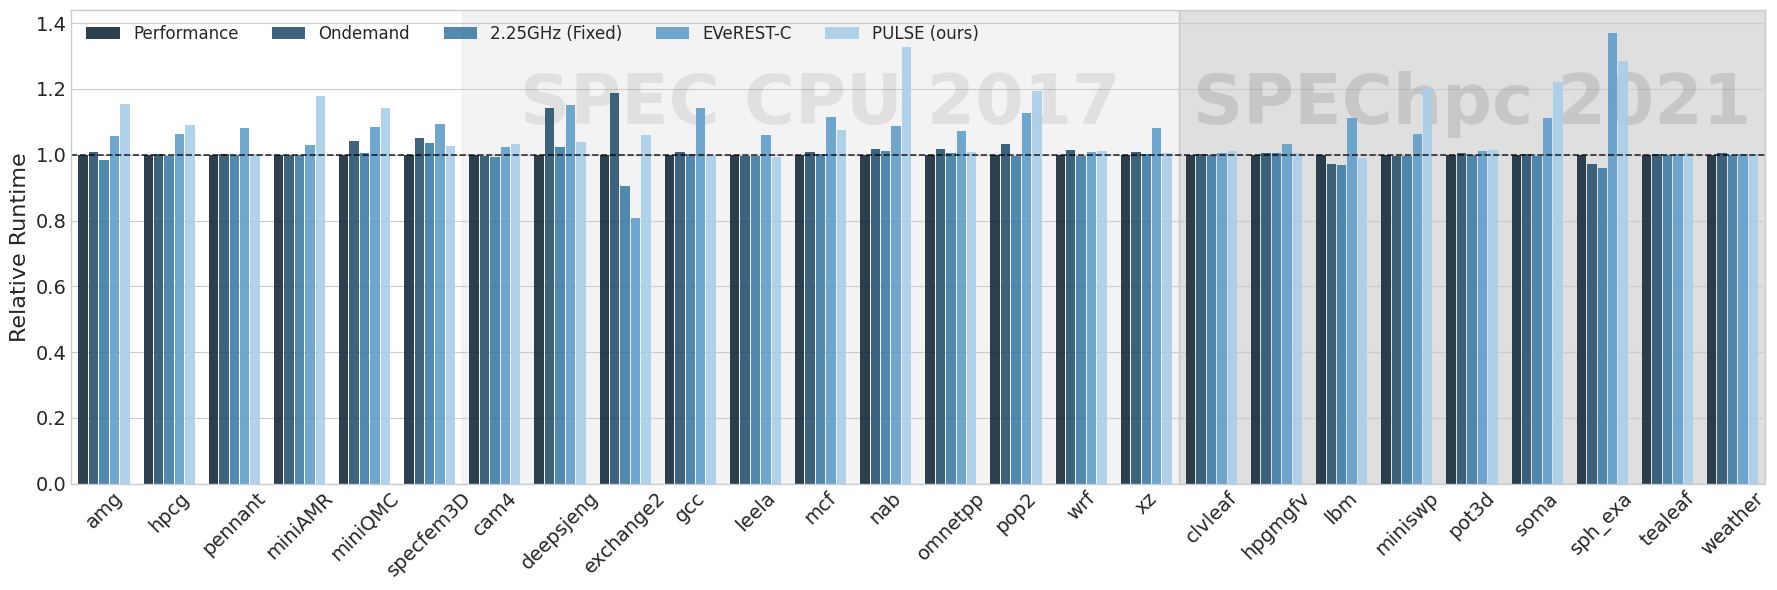

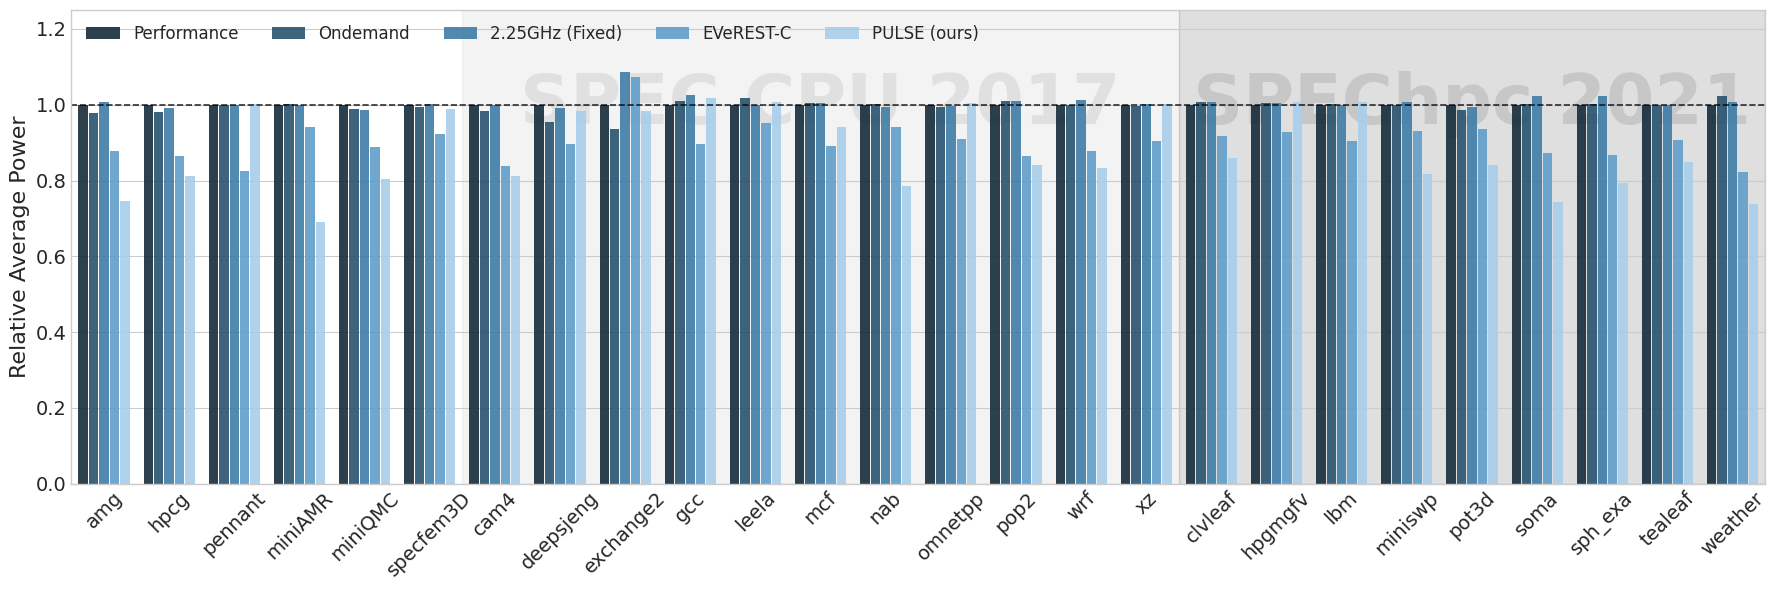

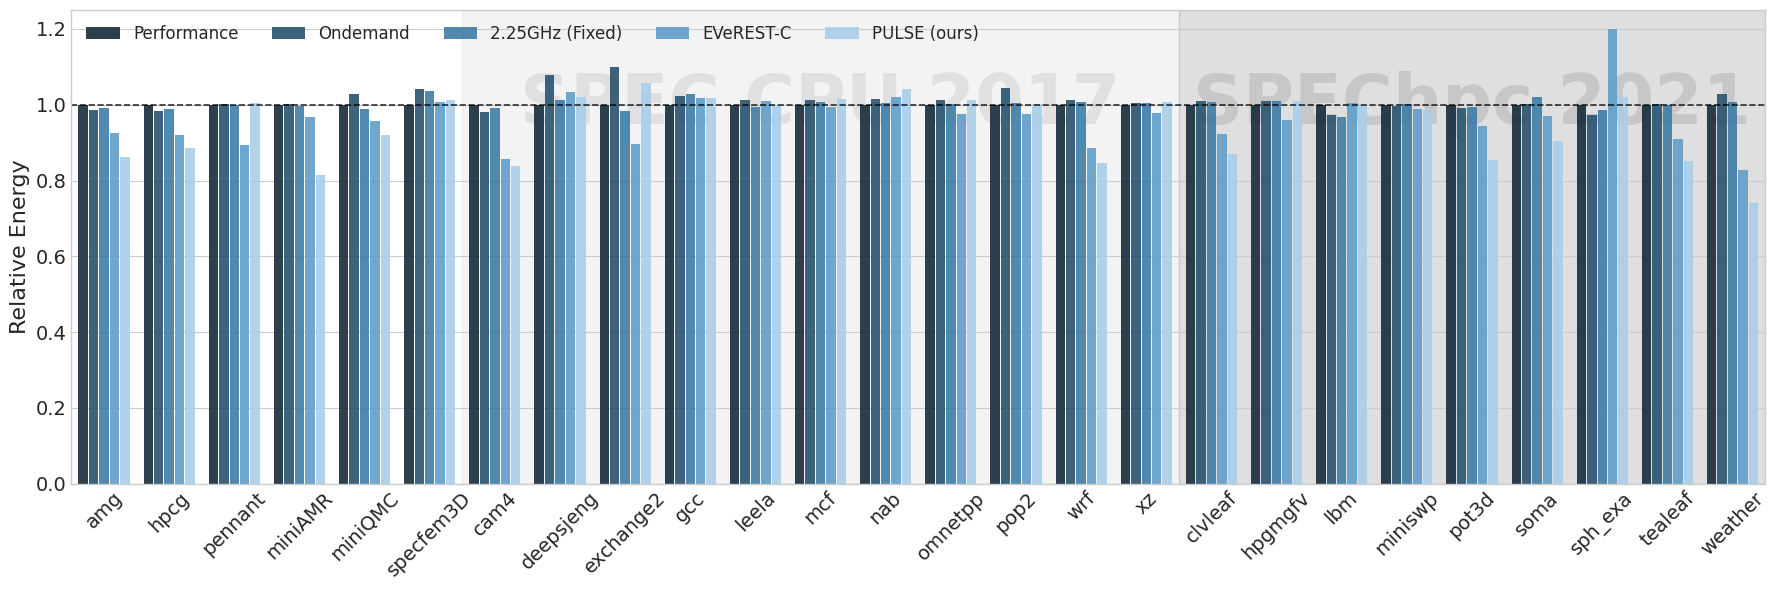

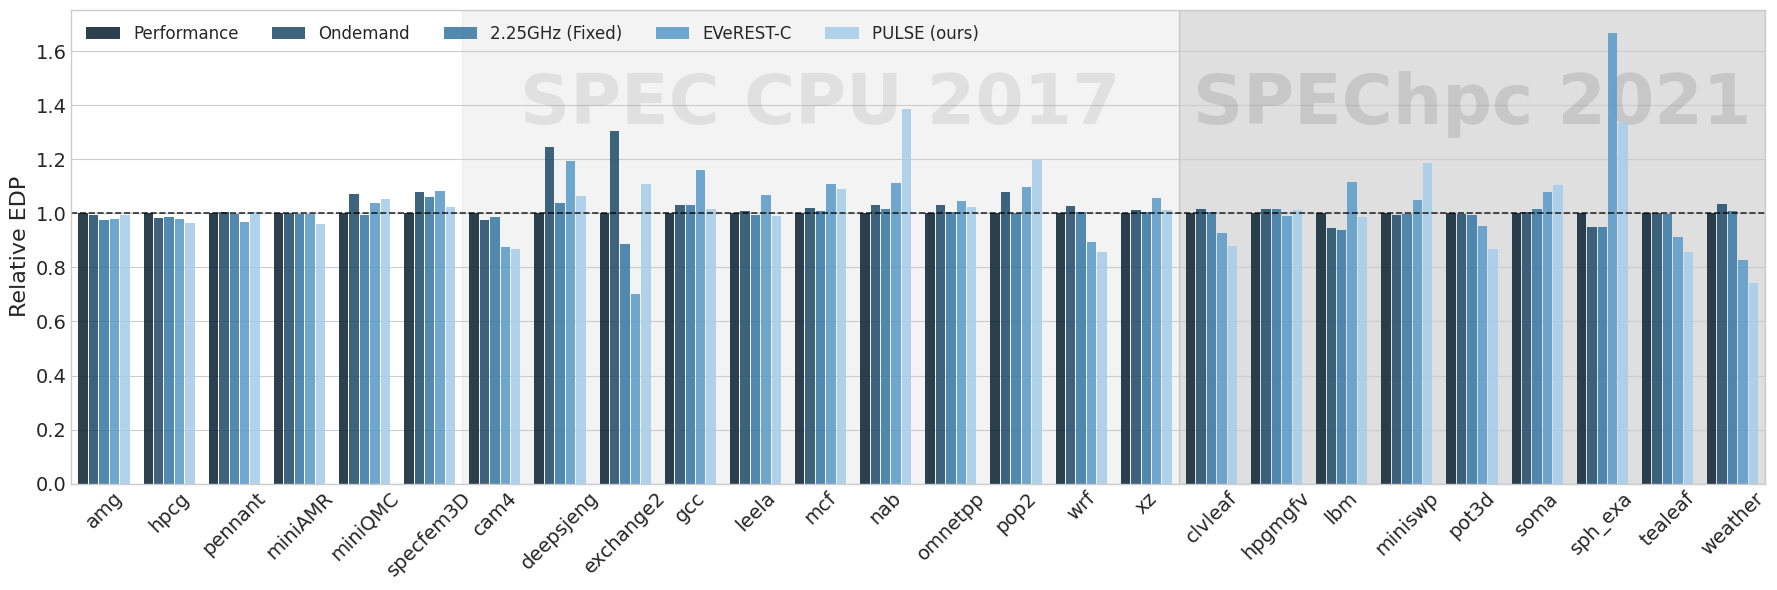

In [29]:
def plot_relative_metric(df: pd.DataFrame, metric: str, governors: list[str]) -> None:
    rel_col = f'{metric}_relative'
    ylabel_map = {
        'Total runtime [s]': 'Relative Runtime',
        'Average total power [W]': 'Relative Average Power',
        'Total energy [J]': 'Relative Energy',
        'EDP [J*s]': 'Relative EDP',
    }

    piv = df.pivot_table(index=['suite', 'benchmark'], columns='governor', values=rel_col, aggfunc='first')
    piv = piv[~piv.index.get_level_values('benchmark').isin(EXCLUDED_BENCHMARKS)]
    bench_order = sorted(piv.index.tolist(), key=lambda x: (suite_order_key(str(x[0])), str(x[1])))
    piv = piv.reindex(index=bench_order, columns=governors)

    x = np.arange(len(bench_order), dtype=float)
    n = len(governors)
    slot = 0.8 / n
    width = slot * 0.9

    fig, ax = plt.subplots(figsize=(max(12, 0.7 * len(bench_order)), 6))

    suite_blocks: dict[str, list[tuple[int, int]]] = {}
    if bench_order:
        start = 0
        current_suite = bench_order[0][0]
        for idx in range(1, len(bench_order)):
            suite = bench_order[idx][0]
            if suite != current_suite:
                suite_blocks.setdefault(current_suite, []).append((start, idx - 1))
                start = idx
                current_suite = suite
        suite_blocks.setdefault(current_suite, []).append((start, len(bench_order) - 1))

    for left, right in suite_blocks.get('SPECcpu', []):
        ax.axvspan(left - 0.5, right + 0.5, color=SPECCPU_BG_COLOR, alpha=0.25, zorder=0)

    for left, right in suite_blocks.get('SPECcpu', []):
        center = (left + right) / 2.0
        ax.text(center, 0.8, 'SPEC CPU 2017', transform=ax.get_xaxis_transform(), ha='center', va='center', fontsize=50, color=SPECCPU_TEXT_COLOR, alpha=0.16, weight='bold', zorder=1)
    for left, right in suite_blocks.get('SPEChpc', []):
        center = (left + right) / 2.0
        ax.text(center, 0.8, 'SPEChpc 2021', transform=ax.get_xaxis_transform(), ha='center', va='center', fontsize=50, color=SPECHPC_TEXT_COLOR, alpha=0.2, weight='bold', zorder=1)

    for i, gov in enumerate(governors):
        vals = piv[gov].to_numpy(dtype=float) if gov in piv.columns else np.full(len(bench_order), np.nan)
        pos = x + (i - (n - 1) / 2.0) * slot
        ax.bar(pos, vals, width=width, label=GOVERNOR_LABELS.get(gov, gov), alpha=0.9, color=GOVERNOR_COLORS.get(gov))

    # Extend SPEChpc background to the true right edge of the axis.
    x_right = len(bench_order) - 0.5
    for left, _ in suite_blocks.get('SPEChpc', []):
        ax.axvspan(left - 0.5, x_right, color=SPECHPC_BG_COLOR, alpha=0.25, zorder=0)
    ax.set_xlim(-0.5, len(bench_order) - 0.5)

    ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    if metric == 'Average total power [W]' or metric == 'Total energy [J]':
        ax.set_ylim(0, 1.25)
    # ax.set_title(f'Relative {metric} (vs {BASELINE_GOVERNOR})')
    # ax.set_xlabel('Benchmark', fontsize=14)
    ax.set_ylabel(ylabel_map.get(metric, f'Relative {metric}'), fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels([bench for _, bench in bench_order], rotation=45, ha='center', fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='x', visible=False)
    ax.legend(ncols=min(5, len(governors)), fontsize=12)
    plt.tight_layout()
    # Save the plot
    if SAVE_PLOTS:
        out = OUT_DIR / f"{metric.replace(' ', '_').replace('[', '').replace(']', '').replace('/', '_')}_relative.pdf"
        fig.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()

SAVE_PLOTS = True
for metric in RELATIVE_METRICS:
    plot_relative_metric(relative_summary, metric, GOVERNORS)